In [21]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## **1.Install TensorFlow2 Object Detection Dependencies**

*UrduDetection* is my folder in google drive. Replace it with yours.

Note: Make sure you have changed path to your directory, everywhere.

In [2]:
#cd into the TensorFlow directory in your Google Drive
%cd '/content/gdrive/My Drive/UrduDetection'

#and clone the TensorFlow Model Garden repository
!git clone https://github.com/tensorflow/models.git

#using a older version of repo (21 Sept 2020)
%cd '/content/gdrive/MyDrive/UrduDetection/models'
!git checkout -f e04dafd04d69053d3733bb91d47d0d95bc2c8199

/content/gdrive/My Drive/UrduDetection
fatal: destination path 'models' already exists and is not an empty directory.
/content/gdrive/MyDrive/UrduDetection/models
Checking out files: 100% (2046/2046), done.
HEAD is now at e04dafd0 Add copybara presumbit metadata, and move files to root dir.


In [3]:
# Install the Object Detection API
%%bash
cd /content/gdrive/MyDrive/UrduDetection/models/research
protoc object_detection/protos/*.proto --python_out=.
cp object_detection/packages/tf2/setup.py .
python -m pip install .

Processing /content/gdrive/MyDrive/UrduDetection/models/research
  Created wheel for object-detection: filename=object_detection-0.1-py3-none-any.whl size=1577697 sha256=9d3326971fe4fbef81a6752e46c398fe83ff363445da444c17e28c334cd71732
  Stored in directory: /tmp/pip-ephem-wheel-cache-4b_wt_r9/wheels/d4/23/ec/3fe63ed1ec2494dcd0bbd66eeeb0715d93d7771675940d430e
  Created wheel for avro-python3: filename=avro_python3-1.9.2.1-py3-none-any.whl size=43512 sha256=d04f339c1ad57d4fb5066f25fa17953f1970d9708242c1365eca22bdf7baabe9
  Stored in directory: /root/.cache/pip/wheels/bc/49/5f/fdb5b9d85055c478213e0158ac122b596816149a02d82e0ab1
  Created wheel for dill: filename=dill-0.3.1.1-py3-none-any.whl size=78546 sha256=cc45e107715b26c2e1d5492881d3657cadef1297fefa8cd39382749ea45c0658
  Stored in directory: /root/.cache/pip/wheels/a4/61/fd/c57e374e580aa78a45ed78d5859b3a44436af17e22ca53284f
  Created wheel for future: filename=future-0.18.2-py3-none-any.whl size=491070 sha256=469c39625bb9c8f58a63f518b0

  DEPRECATION: A future pip version will change local packages to be built in-place without first copying to a temporary directory. We recommend you use --use-feature=in-tree-build to test your packages with this new behavior before it becomes the default.
   pip 21.3 will remove support for this functionality. You can find discussion regarding this at https://github.com/pypa/pip/issues/7555.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
multiprocess 0.70.12.2 requires dill>=0.3.4, but you have dill 0.3.1.1 which is incompatible.
google-colab 1.0.0 requires requests~=2.23.0, but you have requests 2.26.0 which is incompatible.
datascience 0.10.6 requires folium==0.2.1, but you have folium 0.8.3 which is incompatible.


In [4]:
import matplotlib
import matplotlib.pyplot as plt

import os
import random
import io
import imageio
import glob
import scipy.misc
import numpy as np
from six import BytesIO
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Javascript
from IPython.display import Image as IPyImage

import tensorflow as tf

from object_detection.utils import label_map_util
from object_detection.utils import config_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.utils import colab_utils
from object_detection.builders import model_builder

%matplotlib inline

In [5]:
#run model builder test
!python /content/gdrive/MyDrive/UrduDetection/models/research/object_detection/builders/model_builder_tf2_test.py

2021-08-19 07:24:09.792206: E tensorflow/stream_executor/cuda/cuda_driver.cc:271] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2021-08-19 07:24:09.792272: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (0774f812546f): /proc/driver/nvidia/version does not exist
Running tests under Python 3.7.11: /usr/bin/python3
[ RUN      ] ModelBuilderTF2Test.test_create_center_net_model
INFO:tensorflow:time(__main__.ModelBuilderTF2Test.test_create_center_net_model): 4.23s
I0819 07:24:14.023135 140326175610752 test_util.py:2189] time(__main__.ModelBuilderTF2Test.test_create_center_net_model): 4.23s
[       OK ] ModelBuilderTF2Test.test_create_center_net_model
[ RUN      ] ModelBuilderTF2Test.test_create_experimental_model
INFO:tensorflow:time(__main__.ModelBuilderTF2Test.test_create_experimental_model): 0.0s
I0819 07:24:14.024617 140326175610752 test_util.py:2189] time(__main__.ModelBuilderTF2Test.t

In [6]:
def load_image_into_numpy_array(path):
  """Load an image from file into a numpy array.

  Puts image into numpy array to feed into tensorflow graph.
  Note that by convention we put it into a numpy array with shape
  (height, width, channels), where channels=3 for RGB.

  Args:
    path: a file path.

  Returns:
    uint8 numpy array with shape (img_height, img_width, 3)
  """
  img_data = tf.io.gfile.GFile(path, 'rb').read()
  image = Image.open(BytesIO(img_data))
  (im_width, im_height) = image.size
  return np.array(image.getdata()).reshape(
      (im_height, im_width, 3)).astype(np.uint8)

def plot_detections(image_np,
                    boxes,
                    classes,
                    scores,
                    category_index,
                    figsize=(12, 16),
                    image_name=None):
  """Wrapper function to visualize detections.

  Args:
    image_np: uint8 numpy array with shape (img_height, img_width, 3)
    boxes: a numpy array of shape [N, 4]
    classes: a numpy array of shape [N]. Note that class indices are 1-based,
      and match the keys in the label map.
    scores: a numpy array of shape [N] or None.  If scores=None, then
      this function assumes that the boxes to be plotted are groundtruth
      boxes and plot all boxes as black with no classes or scores.
    category_index: a dict containing category dictionaries (each holding
      category index `id` and category name `name`) keyed by category indices.
    figsize: size for the figure.
    image_name: a name for the image file.
  """
  image_np_with_annotations = image_np.copy()
  viz_utils.visualize_boxes_and_labels_on_image_array(
      image_np_with_annotations,
      boxes,
      classes,
      scores,
      category_index,
      use_normalized_coordinates=True,
      min_score_thresh=0.8)
  if image_name:
    plt.imsave(image_name, image_np_with_annotations)
  else:
    plt.imshow(image_np_with_annotations)

## **2. Provide Path to Your *Tfrecords files* and *label_map File*.**

In [7]:
# NOTE: Update these TFRecord paths to your TFRecord and label_map(It contains class names)!
UTiV_test_record_fname = '/content/gdrive/MyDrive/Final_datasets/UTiV_Tfrecords/test.record'
UTiV_train_record_fname = '/content/gdrive/MyDrive/Final_datasets/UTiV_Tfrecords/train.record'

#If you want to fine tune model on more than one dataset, add paths of .records to that data here but make sure class lable file must be same for all datasets
AcTiV_train_fname='/content/gdrive/MyDrive/Final_datasets/AcTiV-D_Tfrecords/AcTiV_train.record'
label_map_pbtxt_fname = '/content/gdrive/MyDrive/Final_datasets/AcTiV-D_Tfrecords/label_map.pbtxt'

Your label_map.pbtxt should be like this, items are equal to the number of classes you have. For my case i have one class:



```
item {
      id: 1
      name: 'artifical'
}
```



.
.
.

## **3. Configure Custom TensorFlow2 Object Detection Training Configuration**

> In this section you can specify any model in the [TF2 OD model zoo](https://github.com/tensorflow/models/blob/master/research/object_detection/g3doc/tf2_detection_zoo.md) and set up your training configuration.

*model_name:* Name of config file will be the name of your model

*base_pipeline_file:* Choose from [here](https://github.com/tensorflow/models/tree/master/research/object_detection/configs/tf2)

*pretrained_checkpoint:* Write model name before .tar.gz


In [8]:
##change chosen model to deploy different models available in the TF2 object detection zoo

MODELS_CONFIG = {
    'faster_rcnn_resnet50_v1_640x640_coco17_tpu-8': {
        'model_name': 'faster_rcnn_resnet50_v1_640x640_coco17_tpu-8',
        'base_pipeline_file': 'faster_rcnn_resnet50_v1_640x640_coco17_tpu-8.config',
        'pretrained_checkpoint': 'faster_rcnn_resnet50_v1_640x640_coco17_tpu-8.tar.gz',
        'batch_size': 1
    }
}

chosen_model = 'faster_rcnn_resnet50_v1_640x640_coco17_tpu-8'

num_steps = 40000 #The more steps, the longer the training. Increase if your loss function is still decreasing and validation metrics are increasing. 
num_eval_steps = 500 #Perform evaluation after so many steps

model_name = MODELS_CONFIG[chosen_model]['model_name']
pretrained_checkpoint = MODELS_CONFIG[chosen_model]['pretrained_checkpoint']
base_pipeline_file = MODELS_CONFIG[chosen_model]['base_pipeline_file']
batch_size = MODELS_CONFIG[chosen_model]['batch_size'] #if you can fit a large batch in memory, it may speed up your training

In [ ]:
%mkdir /content/gdrive/MyDrive/UrduDetection/models/research/deploy/
%cd /content/gdrive/MyDrive/UrduDetection/models/research/deploy/
import tarfile
download_tar = 'http://download.tensorflow.org/models/object_detection/tf2/20200711/' + pretrained_checkpoint

!wget {download_tar}
tar = tarfile.open(pretrained_checkpoint)
tar.extractall()
tar.close()

In [ ]:
%cd /content/gdrive/MyDrive/UrduDetection/models/research/deploy
download_config = 'https://raw.githubusercontent.com/tensorflow/models/master/research/object_detection/configs/tf2/' + base_pipeline_file
!wget {download_config}

In [ ]:
#path to your pipeline_file.config
pipeline_fname = '/content/gdrive/MyDrive/UrduDetection/models/research/deploy/' + base_pipeline_file
fine_tune_checkpoint = '/content/gdrive/MyDrive/UrduDetection/models/research/deploy/' + model_name + '/checkpoint/ckpt-0'


def get_num_classes(pbtxt_fname):
    from object_detection.utils import label_map_util
    label_map = label_map_util.load_labelmap(pbtxt_fname)
    categories = label_map_util.convert_label_map_to_categories(
        label_map, max_num_classes=90, use_display_name=True)
    category_index = label_map_util.create_category_index(categories)
    return len(category_index.keys())
num_classes = get_num_classes(label_map_pbtxt_fname)


## **4.Configure pipline_file.config as following:**

Find it /content/gdrive/MyDrive/UrduDetection/models/research/deploy/



In [ ]:
#write custom configuration file by slotting our dataset, model checkpoint, and training parameters into the base pipeline file

import re

%cd /content/gdrive/MyDrive/UrduDetection/models/research/deploy
print('writing custom configuration file')

with open(pipeline_fname) as f:
    s = f.read()
with open('pipeline_file.config', 'w') as f:
    
    # fine_tune_checkpoint
    s = re.sub('fine_tune_checkpoint: ".*?"',
               'fine_tune_checkpoint: "{}"'.format(fine_tune_checkpoint), s)
    
    # tfrecord files train and test.
    s = re.sub(
        '(input_path: ".*?)(PATH_TO_BE_CONFIGURED/train)(.*?")', 'input_path: "{}"'.format(train_record_fname), s)
    s = re.sub(
        '(input_path: ".*?)(PATH_TO_BE_CONFIGURED/val)(.*?")', 'input_path: "{}"'.format(test_record_fname), s)

    # label_map_path
    s = re.sub(
        'label_map_path: ".*?"', 'label_map_path: "{}"'.format(label_map_pbtxt_fname), s)

    # Set training batch_size.
    s = re.sub('batch_size: [0-9]+',
               'batch_size: {}'.format(batch_size), s)

    # Set training steps, num_steps
    s = re.sub('num_steps: [0-9]+',
               'num_steps: {}'.format(num_steps), s)
    
    # Set number of classes num_classes.
    s = re.sub('num_classes: [0-9]+',
               'num_classes: {}'.format(num_classes), s)
    
    #fine-tune checkpoint type
    s = re.sub(
        'fine_tune_checkpoint_type: "classification"', 'fine_tune_checkpoint_type: "{}"'.format('detection'), s)
        
    f.write(s)



If you have more then one dataset for training then open the pipline_file.config file and add input_path like below:

```
train_input_reader: {
  label_map_path: "/content/gdrive/MyDrive/Final_datasets/AcTiV-D_Tfrecords/label_map.pbtxt"
  tf_record_input_reader {
    input_path: ["/content/gdrive/MyDrive/Final_datasets/UTiV_Tfrecords/train.record",
                 "/content/gdrive/MyDrive/Final_datasets/AcTiV-D_Tfrecords/AcTiV_train.record"]
  }
}
```



In [ ]:
%cat /content/gdrive/MyDrive/UrduDetection/models/research/deploy/pipeline.config

model {
  faster_rcnn {
    num_classes: 1
    image_resizer {
      keep_aspect_ratio_resizer {
        min_dimension: 640
        max_dimension: 640
        pad_to_max_dimension: true
      }
    }
    feature_extractor {
      type: "faster_rcnn_resnet50_keras"
      batch_norm_trainable: true
    }
    first_stage_anchor_generator {
      grid_anchor_generator {
        height_stride: 16
        width_stride: 16
        scales: 0.25
        scales: 0.5
        scales: 1.0
        scales: 2.0
        aspect_ratios: 0.5
        aspect_ratios: 1.0
        aspect_ratios: 2.0
      }
    }
    first_stage_box_predictor_conv_hyperparams {
      op: CONV
      regularizer {
        l2_regularizer {
          weight: 0.0
        }
      }
      initializer {
        truncated_normal_initializer {
          stddev: 0.01
        }
      }
    }
    first_stage_nms_score_threshold: 0.0
    first_stage_nms_iou_threshold: 0.7
    first_stage_max_proposals: 300
    first_stage_localization_loss_

In [ ]:
#path to your pipeline.config file
pipeline_file = '/content/gdrive/MyDrive/UrduDetection/models/research/deploy/pipeline.config'
#path where you want to store your model
model_dir = '/content/gdrive/MyDrive/UrduDetection/FineTuning/'

## **5.Train Custom TF2 Object Detector**
pipeline_file: defined above in writing custom training configuration
* model_dir: the location tensorboard logs and saved model checkpoints will save to
* num_train_steps: how long to train for
* num_eval_steps: perform eval on validation set after this many steps

In [ ]:
!python /content/gdrive/MyDrive/UrduDetection/models/research/object_detection/model_main_tf2.py \
    --pipeline_config_path={pipeline_file} \
    --model_dir={model_dir} \
    --alsologtostderr \
    --num_train_steps={num_steps} \
    --sample_1_of_n_eval_examples=1 \
    --num_eval_steps={num_eval_steps}

In [ ]:
#run model evaluation to obtain performance metrics
!python /content/gdrive/MyDrive/UrduDetection/models/research/object_detection/model_main_tf2.py \
    --pipeline_config_path={pipeline_file} \
    --model_dir={model_dir} \
    --checkpoint_dir={model_dir} \
#Not yet implemented for EfficientDet

In [ ]:
%load_ext tensorboard
%tensorboard --logdir '/content/gdrive/MyDrive/UrduDetection/FineTuning/training'#path to store training logs

## **6.Exporting a Trained Inference Graph**


Still to come for TF2 models, we will be updating this Colab notebook accordingly as the functionality is added. 

In [ ]:
#see where our model saved weights
%ls '/content/gdrive/MyDrive/UrduDetection/FineTuning/'

In [ ]:
#run conversion script
import re
import numpy as np

output_directory = '/content/gdrive/MyDrive/UrduDetection/FineTunedModel'

#place the model weights you would like to export here
last_model_path = '/content/gdrive/MyDrive/UrduDetection/FineTuning/'
print(last_model_path)
!python /content/gdrive/MyDrive/UrduDetection/models/research/object_detection/exporter_main_v2.py \
    --trained_checkpoint_dir {last_model_path} \
    --output_directory {output_directory} \
    --pipeline_config_path {pipeline_file}

In [ ]:
%ls '/content/gdrive/MyDrive/UrduDetection/FineTunedModel/saved_model/'

## **7.Run Inference on Test Images with Custom TensorFlow2 Object Detecto**r

In [9]:
import matplotlib
import matplotlib.pyplot as plt

import io
import scipy.misc
import numpy as np
from six import BytesIO
from PIL import Image, ImageDraw, ImageFont

import tensorflow as tf

from object_detection.utils import label_map_util
from object_detection.utils import config_util
from object_detection.utils import visualization_utils as viz_utils
from object_detection.builders import model_builder

%matplotlib inline

In [10]:
def load_image_into_numpy_array(path):
  """Load an image from file into a numpy array.

  Puts image into numpy array to feed into tensorflow graph.
  Note that by convention we put it into a numpy array with shape
  (height, width, channels), where channels=3 for RGB.

  Args:
    path: the file path to the image

  Returns:
    uint8 numpy array with shape (img_height, img_width, 3)
  """
  img_data = tf.io.gfile.GFile(path, 'rb').read()
  image = Image.open(BytesIO(img_data))
  (im_width, im_height) = image.size
  return np.array(image.getdata()).reshape(
      (im_height, im_width, 3)).astype(np.uint8)

In [ ]:
%ls '/content/gdrive/MyDrive/UrduDetection/FineTuning/'

In [17]:
import pathlib

filenames = list(pathlib.Path('/content/gdrive/MyDrive/UrduDetection/ReModelTraining/').glob('*.index'))

filenames.sort()
print(filenames)

#recover our saved model
pipeline_config = pipeline_file
#generally you want to put the last ckpt from training in here
model_dir = str(filenames[-1]).replace('.index','')
configs = config_util.get_configs_from_pipeline_file(pipeline_config)
model_config = configs['model']
detection_model = model_builder.build(
      model_config=model_config, is_training=False)

# Restore checkpoint
ckpt = tf.compat.v2.train.Checkpoint(
      model=detection_model)
ckpt.restore(os.path.join(str(filenames[-1]).replace('.index','')))


def get_model_detection_function(model):
  """Get a tf.function for detection."""

  @tf.function
  def detect_fn(image):
    """Detect objects in image."""

    image, shapes = model.preprocess(image)
    prediction_dict = model.predict(image, shapes)
    detections = model.postprocess(prediction_dict, shapes)

    return detections, prediction_dict, tf.reshape(shapes, [-1])

  return detect_fn

detect_fn = get_model_detection_function(detection_model)

[PosixPath('/content/gdrive/MyDrive/UrduDetection/ReModelTraining/ckpt-1.index'), PosixPath('/content/gdrive/MyDrive/UrduDetection/ReModelTraining/ckpt-2.index'), PosixPath('/content/gdrive/MyDrive/UrduDetection/ReModelTraining/ckpt-3.index'), PosixPath('/content/gdrive/MyDrive/UrduDetection/ReModelTraining/ckpt-4.index'), PosixPath('/content/gdrive/MyDrive/UrduDetection/ReModelTraining/ckpt-5.index')]


In [18]:
#map labels for inference decoding
label_map_path = configs['eval_input_config'].label_map_path
label_map = label_map_util.load_labelmap(label_map_path)
categories = label_map_util.convert_label_map_to_categories(
    label_map,
    max_num_classes=label_map_util.get_max_label_map_index(label_map),
    use_display_name=True)
category_index = label_map_util.create_category_index(categories)
label_map_dict = label_map_util.get_label_map_dict(label_map, use_display_name=True)

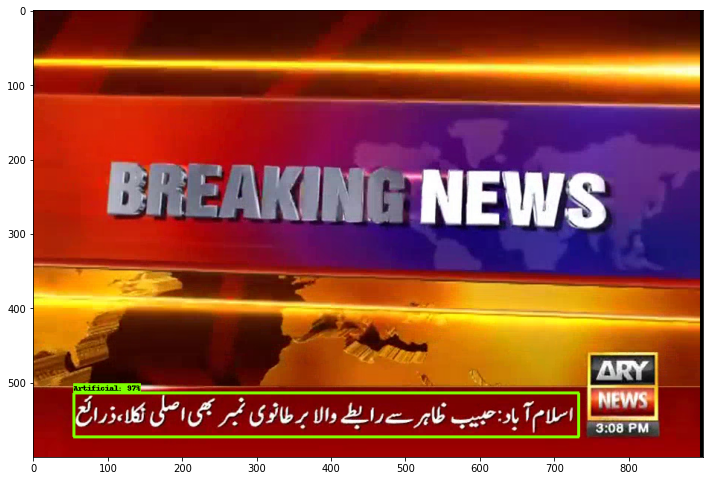

In [20]:
#run detector on test image
#it takes a little longer on the first run and then runs at normal speed. 
import random

TEST_IMAGE_PATHS = glob.glob('/content/gdrive/MyDrive/Final_datasets/Data_test/*.jpg')
image_path = random.choice(TEST_IMAGE_PATHS)
image_np = load_image_into_numpy_array(image_path)

# Things to try:
# Flip horizontally
# image_np = np.fliplr(image_np).copy()

# Convert image to grayscale
# image_np = np.tile(
#     np.mean(image_np, 2, keepdims=True), (1, 1, 3)).astype(np.uint8)

input_tensor = tf.convert_to_tensor(
    np.expand_dims(image_np, 0), dtype=tf.float32)
detections, predictions_dict, shapes = detect_fn(input_tensor)

label_id_offset = 1
image_np_with_detections = image_np.copy()

viz_utils.visualize_boxes_and_labels_on_image_array(
      image_np_with_detections,
      detections['detection_boxes'][0].numpy(),
      (detections['detection_classes'][0].numpy() + label_id_offset).astype(int),
      detections['detection_scores'][0].numpy(),
      category_index,
      use_normalized_coordinates=True,
      max_boxes_to_draw=200,
      min_score_thresh=.5,
      agnostic_mode=False,
)

plt.figure(figsize=(12,16))
plt.imshow(image_np_with_detections)
plt.show()

## **8.Get Coordinate Values of Detected Regions and Crop those Regions**

In [ ]:
#run detector on test image
#it takes a little longer on the first run and then runs at normal speed.
import os
import cv2
import csv
import random
import pandas as pd
from PIL import Image
from csv import writer
from csv import reader


count=0
TEST_IMAGE_PATHS =   glob.glob('/content/gdrive/MyDrive/Final_datasets/Data_test/*.jpg')
for image_path in TEST_IMAGE_PATHS:
    #image_path = random.choice(TEST_IMAGE_PATHS)

    file_name_ext=os.path.basename(image_path)
    file_name=os.path.splitext(file_name_ext)[0]

    image_np = load_image_into_numpy_array(image_path)
    img = Image.open(image_path)
    # image_np = cv2.imread(image_path)

    # Things to try:
    # Flip horizontally
    # image_np = np.fliplr(image_np).copy()

    # Convert image to grayscale
    # image_np = np.tile(
    #     np.mean(image_np, 2, keepdims=True), (1, 1, 3)).astype(np.uint8)

    input_tensor = tf.convert_to_tensor(
    np.expand_dims(image_np, 0), dtype=tf.float32)
    detections, predictions_dict, shapes = detect_fn(input_tensor)


    height, width, _ = image_np.shape

    i = 1
    list1=[]

    for box,score,cls in zip(detections['detection_boxes']  [0],detections['detection_scores'][0],detections['detection_classes'][0]):
        file_name_fno=file_name+"-"+str(i)
        if score >= 0.5: # or any other value
            xmin = int(box[1]*width)
            ymin = int(box[0]*height)
            xmax = int(box[3]*width)
            ymax = int(box[2]*height)
            list1.append((file_name_fno,xmin,ymin,xmax,ymax))
            i+=1

    #print(count," :- ",list1)

    for i in list1:
        with open('/content/gdrive/MyDrive/Final_datasets/Data_test/Coordinates/Data_test.csv','a',newline='') as fd:
            writer_object = csv.writer(fd)
            writer_object.writerow(i)
    #print(list1)


    label_id_offset = 1
    image_np_with_detections = image_np.copy()

    viz_utils.visualize_boxes_and_labels_on_image_array(
          image_np_with_detections,
          detections['detection_boxes'][0].numpy(),
          (detections['detection_classes'][0].numpy() + label_id_offset).astype(int),
          detections['detection_scores'][0].numpy(),
          category_index,
          use_normalized_coordinates=True,
          max_boxes_to_draw=200,
          min_score_thresh=.5,
          agnostic_mode=False,
    )
    print(count," :- ",list1)
    count=count+1

print("Completed!.........................!")

0  :-  [('Dunya_News_20170417_030312_41401-1', 68, 516, 708, 569), ('Dunya_News_20170417_030312_41401-2', 83, 53, 174, 84)]
1  :-  [('ARY_News_20170413_150833_37626-1', 54, 514, 733, 572)]
2  :-  [('Express_News_20170413_170833_26551-1', 81, 521, 682, 572), ('Express_News_20170413_170833_26551-2', 706, 485, 827, 513)]
3  :-  [('Express_News_20170413_170833_44851-1', 74, 521, 683, 574), ('Express_News_20170413_170833_44851-2', 709, 488, 831, 518), ('Express_News_20170413_170833_44851-3', 721, 545, 813, 573)]
Completed!.........................!


In [ ]:
path="/content/gdrive/MyDrive/Final_datasets/Data_test"

with open('/content/gdrive/MyDrive/Final_datasets/Data_test/Coordinates/Data_test.csv', 'r') as read_obj:
    csv_reader = reader(read_obj)
    dir_name="/content/gdrive/MyDrive/Final_datasets/Data_test/Cropped/"
    for row in csv_reader:
        row_list = row
        print(row_list)
      
        xmin=int(row_list[1])
        ymin=int(row_list[2])
        xmax=int(row_list[3])
        ymax=int(row_list[4])
        file_name_coordinates=row_list[0]
        file_name=file_name_coordinates.split('-')[0]
        open_image=path+'/'+file_name+".jpg"
        print(open_image)
        #print(file_name)
        
        img = Image.open(open_image)
        cropped_img=img.crop((xmin,ymin,xmax,ymax))
        cropped = cropped_img.save(dir_name+row_list[0]+".jpg")
        #i += 1


['Dunya_News_20170417_030312_41401-1', '68', '516', '708', '569']
/content/gdrive/MyDrive/Final_datasets/Data_test/Dunya_News_20170417_030312_41401.jpg
['Dunya_News_20170417_030312_41401-2', '83', '53', '174', '84']
/content/gdrive/MyDrive/Final_datasets/Data_test/Dunya_News_20170417_030312_41401.jpg
['ARY_News_20170413_150833_37626-1', '54', '514', '733', '572']
/content/gdrive/MyDrive/Final_datasets/Data_test/ARY_News_20170413_150833_37626.jpg
['Express_News_20170413_170833_26551-1', '81', '521', '682', '572']
/content/gdrive/MyDrive/Final_datasets/Data_test/Express_News_20170413_170833_26551.jpg
['Express_News_20170413_170833_26551-2', '706', '485', '827', '513']
/content/gdrive/MyDrive/Final_datasets/Data_test/Express_News_20170413_170833_26551.jpg
['Express_News_20170413_170833_44851-1', '74', '521', '683', '574']
/content/gdrive/MyDrive/Final_datasets/Data_test/Express_News_20170413_170833_44851.jpg
['Express_News_20170413_170833_44851-2', '709', '488', '831', '518']
/content/gdr